In [ ]:
!pip install torch==1.9.0+cu111 torchvision==0.10.0+cu111 -f https://download.pytorch.org/whl/torch_stable.html

!pip install click requests tqdm pyspng ninja imageio-ffmpeg==0.4.3
!pip install psutil scipy matplotlib opencv-python pillow

Defaulting to user installation because normal site-packages is not writeable


Looking in links: https://download.pytorch.org/whl/torch_stable.html
     ━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.6/2.0 GB 110.8 MB/s eta 0:00:13
ERROR: Operation cancelled by user
^C
Traceback (most recent call last):
  File "/bin/pip", line 24, in <module>
    sys.exit(main())
  File "/users/eleves-a/2023/roman.lendormy/.local/lib/python3.9/site-packages/pip/_internal/cli/main.py", line 85, in main
    return command.main(cmd_args)
  File "/users/eleves-a/2023/roman.lendormy/.local/lib/python3.9/site-packages/pip/_internal/cli/base_command.py", line 159, in main
    return self._main(args)
  File "/usr/lib64/python3.9/contextlib.py", line 126, in __exit__
    next(self.gen)
  File "/users/eleves-a/2023/roman.lendormy/.local/lib/python3.9/site-packages/pip/_internal/cli/command_context.py", line 21, in main_context
    yield
  File "/usr/lib64/python3.9/contextlib.py", line 532, in __exit__
    raise exc_details[1]
  File "/usr/lib64/python3.9/contextlib.py", line 137, in __exit__


In [2]:
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git
!cd stylegan2-ada-pytorch

Cloning into 'stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 129 (from 2)
Receiving objects: 100% (131/131), 1.13 MiB | 4.12 MiB/s, done.
Resolving deltas: 100% (57/57), done.


# Downloading the shoes dataset from kaggle

In [1]:
import os
import kagglehub

os.environ["KAGGLEHUB_CACHE"] = "/Data/roman.lendormy/.kaggle_cache"
path = kagglehub.dataset_download(
    "aryashah2k/large-shoe-dataset-ut-zappos50k"
)

print(path)


/users/eleves-a/2023/roman.lendormy/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 853M/853M [00:21<00:00, 40.8MB/s] 

Extracting files...


/Data/roman.lendormy/.kaggle_cache/datasets/aryashah2k/large-shoe-dataset-ut-zappos50k/versions/1


In [ ]:
#Dataset de chaussures de Zappos

import os
from PIL import Image
import matplotlib.pyplot as plt
import kagglehub

dataset_path = kagglehub.dataset_download(
    "aryashah2k/large-shoe-dataset-ut-zappos50k"
 )  # chemin retourné par kagglehub

# Extensions images acceptées
image_extensions = (".jpg", ".jpeg", ".png")

# Récupérer toutes les images récursivement
all_images = []

for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            all_images.append(os.path.join(root, file))

print(f"Nombre total d'images trouvées : {len(all_images)}")

# Prendre les 10 premières
first_10 = all_images[:10]

# Affichage
plt.figure(figsize=(15, 8))

for i, img_path in enumerate(first_10):
    img = Image.open(img_path).convert("RGB")
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path), fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [1]:
#Afficher le format en pixel des images du shoe dataset
for img_path in first_10:
    img = Image.open(img_path).convert("RGB")
    print(f"{os.path.basename(img_path)}: {img.size} pixels")

NameError: name 'first_10' is not defined

7941111.342897.jpg
7941111.342897.jpg: (136, 102) pixels


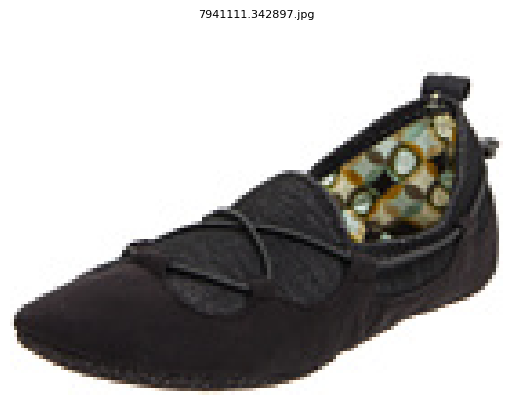

In [27]:
import os
!ls /Data/roman.lendormy/.kaggle_cache/datasets/aryashah2k/large-shoe-dataset-ut-zappos50k/versions/1/ut-zap50k-images/ut-zap50k-images/Shoes/Flats/Acorn
#open the first image of the shoe datastet and display it with its size in pixels
img_path = "/Data/roman.lendormy/.kaggle_cache/datasets/aryashah2k/large-shoe-dataset-ut-zappos50k/versions/1/ut-zap50k-images/ut-zap50k-images/Shoes/Flats/Acorn/7941111.342897.jpg"
img = Image.open(img_path).convert("RGB")
print(f"{os.path.basename(img_path)}: {img.size} pixels")
plt.imshow(img)
plt.title(os.path.basename(img_path), fontsize=8)
plt.axis("off")
plt.show()


# Formating the shoes dataset - square 128x128 px

In [41]:
!ls '/Data/roman.lendormy/.kaggle_cache/datasets/aryashah2k/large-shoe-dataset-ut-zappos50k/versions/1/ut-zap50k-images'

ut-zap50k-images


In [3]:
import os
from PIL import Image

input_root = '/Data/roman.lendormy/.kaggle_cache/datasets/aryashah2k/large-shoe-dataset-ut-zappos50k/versions/1/ut-zap50k-images'
output_root = "/Data/roman.lendormy/shoes_format_128/"

os.makedirs(output_root, exist_ok=True)

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def process_image(input_path, output_path, size=128):
    img = Image.open(input_path).convert("RGB")
    w, h = img.size

    scale = size / max(w, h)
    new_w = int(w * scale)
    new_h = int(h * scale)

    img_resized = img.resize((new_w, new_h), Image.LANCZOS)

    new_img = Image.new("RGB", (size, size), (255, 255, 255))

    paste_x = (size - new_w) // 2
    paste_y = (size - new_h) // 2

    new_img.paste(img_resized, (paste_x, paste_y))
    new_img.save(output_path, quality=95)


counter = 0

for root, _, files in os.walk(input_root):
    for file in files:
        if file.lower().endswith(valid_extensions):
            input_path = os.path.join(root, file)

            try:
                output_filename = f"shoe_{counter:06d}.jpg"
                output_path = os.path.join(output_root, output_filename)

                process_image(input_path, output_path)
                counter += 1

                if counter % 1000 == 0:
                    print(f"{counter} images traitées...")

            except Exception:
                continue

print(f"✅ Terminé. {counter} images sauvegardées.")

1000 images traitées...
2000 images traitées...
3000 images traitées...
4000 images traitées...
5000 images traitées...
6000 images traitées...
7000 images traitées...
8000 images traitées...
9000 images traitées...
10000 images traitées...
11000 images traitées...
12000 images traitées...
13000 images traitées...
14000 images traitées...
15000 images traitées...
16000 images traitées...
17000 images traitées...
18000 images traitées...
19000 images traitées...
20000 images traitées...
21000 images traitées...
22000 images traitées...
23000 images traitées...
24000 images traitées...
25000 images traitées...
26000 images traitées...
27000 images traitées...
28000 images traitées...
29000 images traitées...
30000 images traitées...
31000 images traitées...
32000 images traitées...
33000 images traitées...
34000 images traitées...
35000 images traitées...
36000 images traitées...
37000 images traitées...
38000 images traitées...
39000 images traitées...
40000 images traitées...
41000 ima

In [4]:
#imprimer le nombre d'images dans le dossier de sortie
output_images = [f for f in os.listdir(output_root) if f.lower().endswith(valid_extensions)]
print(f"Nombre d'images dans le dossier de sortie : {len(output_images)}")

Nombre d'images dans le dossier de sortie : 50025


10 premières images traitées :


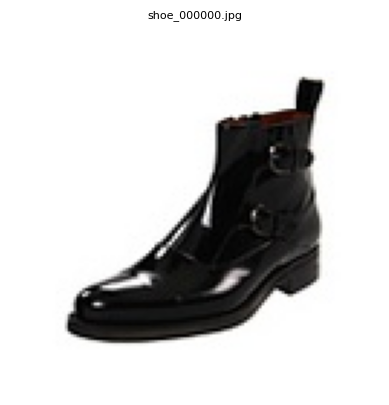

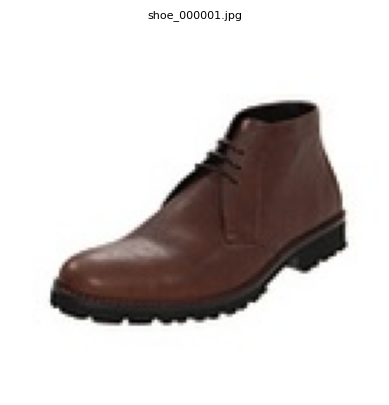

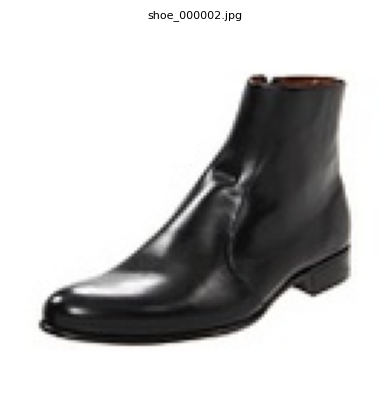

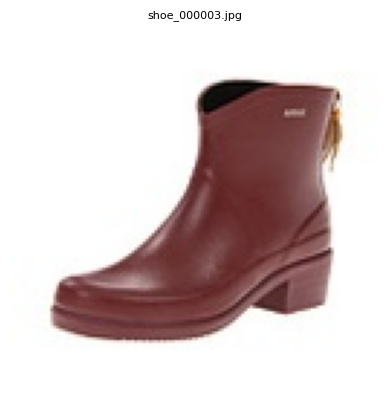

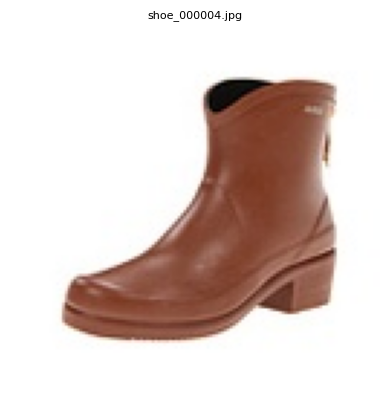

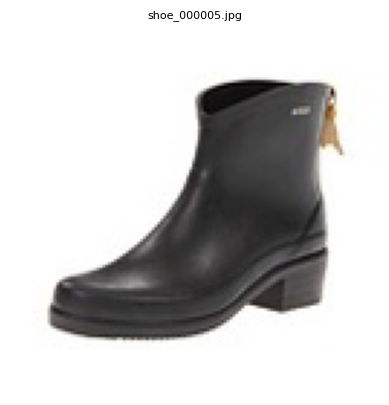

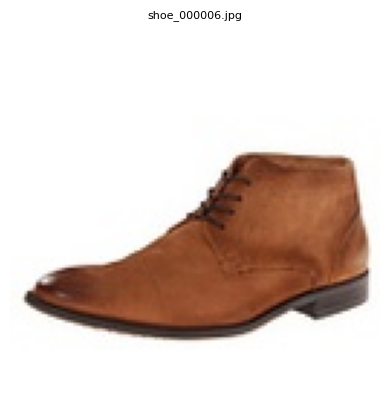

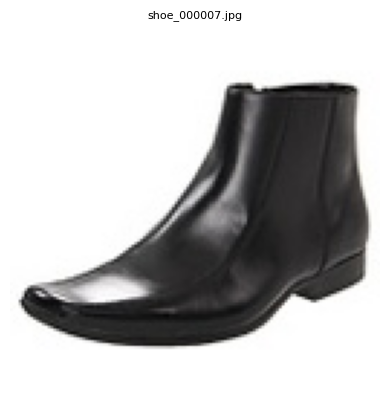

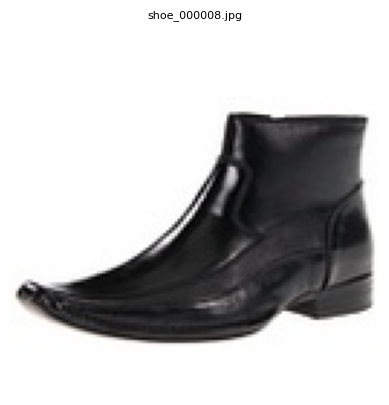

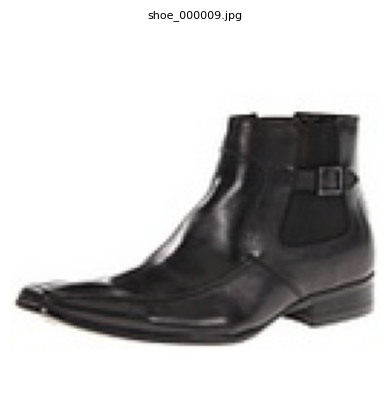

In [6]:
#print top 10 images
import matplotlib.pyplot as plt
print("10 premières images traitées :")
for i, img_file in enumerate(sorted(os.listdir(output_root))[:10]):
    img = Image.open(os.path.join(output_root, img_file))
    plt.imshow(img)
    plt.title(img_file, fontsize=8)
    plt.axis("off")
    plt.show()

# Same with another sneakers dataset

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


100%|██████████| 1.09G/1.09G [00:26<00:00, 44.7MB/s]

Extracting files...


Nombre total d'images trouvées : 23946


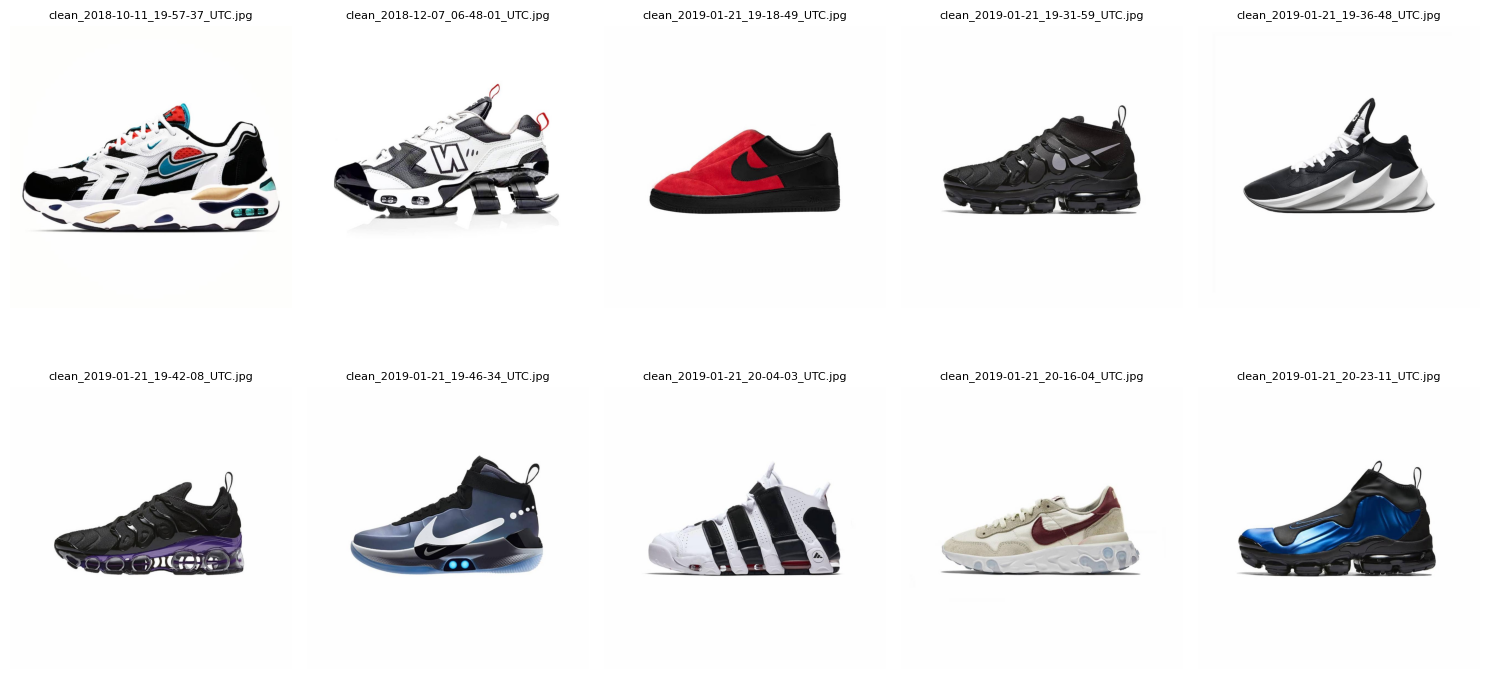

In [49]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import kagglehub
import os
import kagglehub

os.environ["KAGGLEHUB_CACHE"] = "/Data/roman.lendormy/.kaggle_cache"

dataset_path = kagglehub.dataset_download(
    "aahashemi/sneaker-image-dataset"
 )  # chemin retourné par kagglehub

# Extensions images acceptées
image_extensions = (".jpg", ".jpeg", ".png")

# Récupérer toutes les images récursivement
all_images = []

for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            all_images.append(os.path.join(root, file))

print(f"Nombre total d'images trouvées : {len(all_images)}")

# Prendre les 10 premières
first_10 = all_images[:10]

# Affichage
plt.figure(figsize=(15, 8))

for i, img_path in enumerate(first_10):
    img = Image.open(img_path).convert("RGB")
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path), fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


1000 images traitées...
2000 images traitées...
3000 images traitées...
4000 images traitées...
5000 images traitées...
6000 images traitées...
7000 images traitées...
8000 images traitées...
9000 images traitées...
10000 images traitées...
11000 images traitées...
12000 images traitées...
13000 images traitées...
14000 images traitées...
15000 images traitées...
16000 images traitées...
17000 images traitées...
18000 images traitées...
19000 images traitées...
20000 images traitées...
21000 images traitées...
22000 images traitées...
23000 images traitées...
✅ Normalisation terminée (23946 images).
10 premières images traitées :
sneaker_000000.jpg: (128, 128) pixels


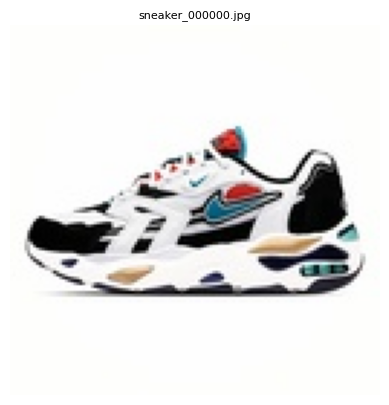

sneaker_000001.jpg: (128, 128) pixels


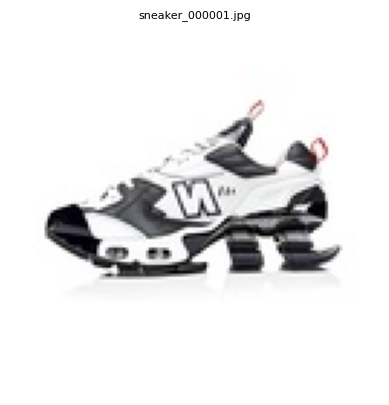

sneaker_000002.jpg: (128, 128) pixels


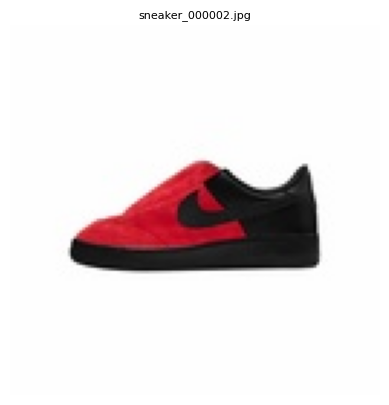

sneaker_000003.jpg: (128, 128) pixels


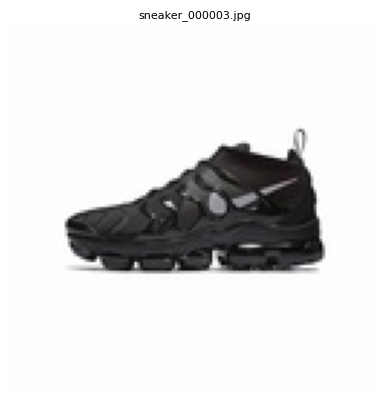

sneaker_000004.jpg: (128, 128) pixels


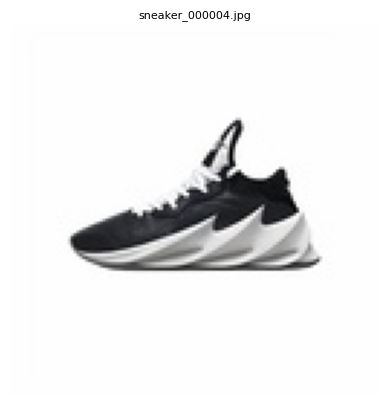

sneaker_000005.jpg: (128, 128) pixels


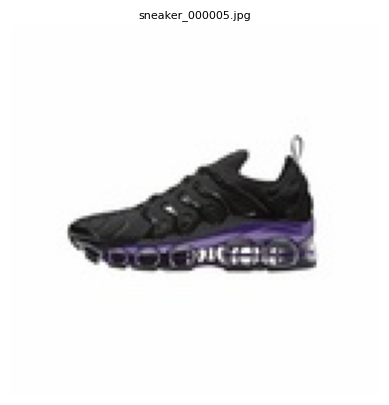

sneaker_000006.jpg: (128, 128) pixels


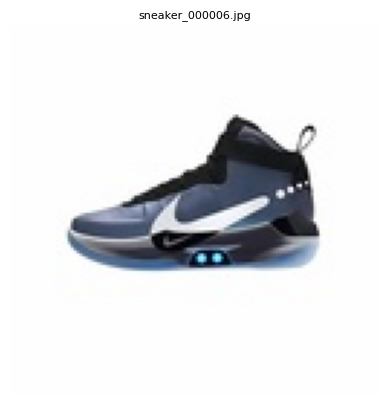

sneaker_000007.jpg: (128, 128) pixels


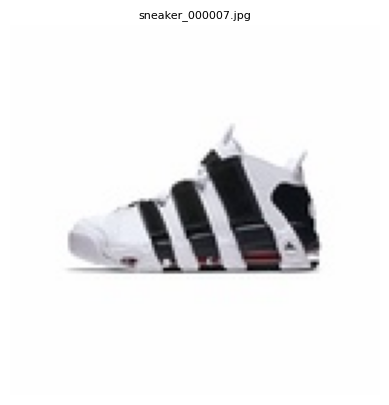

sneaker_000008.jpg: (128, 128) pixels


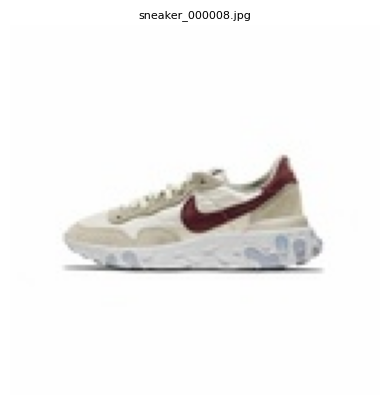

sneaker_000009.jpg: (128, 128) pixels


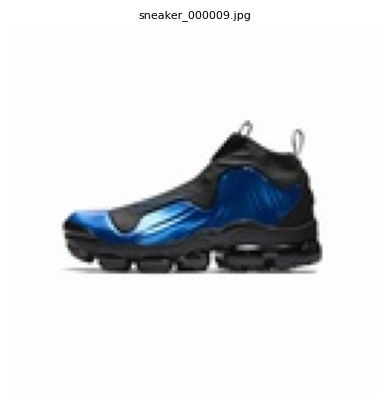

In [55]:
import os
from PIL import Image

# 📁 Chemin du dataset sneakers Kaggle
input_root = "/Data/roman.lendormy/.kaggle_cache/datasets/aahashemi/sneaker-image-dataset/versions/1/sneaker_images_1024x1024"
# 📁 Dossier de sortie
output_root = "/Data/roman.lendormy/shoes/shoes_sneakers_format_128"

os.makedirs(output_root, exist_ok=True)

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def process_image(input_path, output_path, size=128):
    img = Image.open(input_path).convert("RGB")
    w, h = img.size

    # On réduit tout en gardant le plus grand côté = 128
    scale = size / max(w, h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    img_resized = img.resize((new_w, new_h), Image.LANCZOS)

    # Image carrée blanche 128x128
    new_img = Image.new("RGB", (size, size), (255, 255, 255))
    paste_x = (size - new_w) // 2
    paste_y = (size - new_h) // 2

    new_img.paste(img_resized, (paste_x, paste_y))
    new_img.save(output_path, quality=95)

counter = 0

for root, _, files in os.walk(input_root):
    for file in files:
        if file.lower().endswith(valid_extensions):
            input_path = os.path.join(root, file)

            try:
                output_filename = f"sneaker_{counter:06d}.jpg"
                output_path = os.path.join(output_root, output_filename)

                process_image(input_path, output_path)
                counter += 1

                if counter % 1000 == 0:
                    print(f"{counter} images traitées...")

            except Exception as e:
                print(f"Erreur avec {input_path}: {e}")
                continue

print(f"✅ Normalisation terminée ({counter} images).")
#print the first ten with dimensions
print("10 premières images traitées :")
for i, img_file in enumerate(sorted(os.listdir(output_root))[:10]):
    img = Image.open(os.path.join(output_root, img_file))
    print(f"{img_file}: {img.size} pixels")
    plt.imshow(img)
    plt.title(img_file, fontsize=8)
    plt.axis("off")
    plt.show()

In [8]:
import os
import shutil

input_dirs = [
    "/Data/roman.lendormy/shoes/shoes_sneakers_format_128",
    "/Data/roman.lendormy/shoes/shoes_format_128"
]

#compter nombre d'images dans les dossiers
for input_dir in input_dirs:
    count = sum(len(files) for _, _, files in os.walk(input_dir))
    print(f"{input_dir}: {count} images")

/Data/roman.lendormy/shoes/shoes_sneakers_format_128: 23946 images
/Data/roman.lendormy/shoes/shoes_format_128: 50025 images


In [9]:
import os
import shutil

input_dirs = [
    "/Data/roman.lendormy/shoes/shoes_sneakers_format_128",
    "/Data/roman.lendormy/shoes/shoes_format_128"
]

output_dir = "/Data/roman.lendormy/shoes/merged"
os.makedirs(output_dir, exist_ok=True)

valid_extensions = (".jpg", ".jpeg", ".png", ".webp")

counter = 0

for input_root in input_dirs:
    for root, _, files in os.walk(input_root):
        for file in files:
            if file.lower().endswith(valid_extensions):
                src_path = os.path.join(root, file)

                new_filename = f"shoe_{counter:06d}.jpg"
                dst_path = os.path.join(output_dir, new_filename)

                try:
                    shutil.copy2(src_path, dst_path)
                    counter += 1
                except Exception:
                    continue

print(f"✅ Fusion terminée : {counter} images copiées.")

✅ Fusion terminée : 73971 images copiées.


In [12]:
import zipfile
import os

input_dir = "/Data/roman.lendormy/shoes/merged"
zip_path = "/Data/roman.lendormy/s2p_dataset_processed/shoes_128.zip"

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_STORED) as zf:
    for file in os.listdir(input_dir):
        full_path = os.path.join(input_dir, file)
        if os.path.isfile(full_path):
            zf.write(full_path, arcname=file)

print("✅ ZIP prêt pour StyleGAN.")

✅ ZIP prêt pour StyleGAN.


# Downloading the handbag dataset

In [2]:
#Pas ok en fait. Ne contient pas handbags. Mais un edge2shoes.
import os

os.environ["KAGGLEHUB_CACHE"] = "/Data/roman.lendormy/.kaggle_cache"

import kagglehub

dataset_handle = "vikramtiwari/pix2pix-dataset"

path = kagglehub.dataset_download(dataset_handle)

print("Dataset téléchargé dans :", path)


100%|██████████| 2.40G/2.40G [01:07<00:00, 38.0MB/s]

Extracting files...


Dataset téléchargé dans : /Data/roman.lendormy/.kaggle_cache/datasets/vikramtiwari/pix2pix-dataset/versions/2


In [3]:
import tensorflow as tf
import pathlib
import os

# Chemin où tu veux stocker le dataset
target_dir = "/Data/roman.lendormy/.kaggle_cache"

# Crée le dossier s'il n'existe pas
os.makedirs(target_dir, exist_ok=True)

# Nom du dataset pix2pix
dataset_name = "edges2handbags"
_URL = f"http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/{dataset_name}.tar.gz"

# Téléchargement et extraction
path_to_zip = tf.keras.utils.get_file(
    fname=f"{dataset_name}.tar.gz",
    origin=_URL,
    extract=True,
    cache_dir=target_dir,
    cache_subdir=""   # pour extraire directement dans target_dir
)

# Chemin final vers le dossier du dataset
PATH = pathlib.Path(path_to_zip).parent / dataset_name
print("Dataset téléchargé dans :", PATH)


8556411008/8556411008 ━━━━━━━━━━━━━━━━━━━━ 3177s 0us/step
Dataset téléchargé dans : /Data/roman.lendormy/.kaggle_cache/edges2handbags


I0000 00:00:1771336330.504452 1859619 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13876 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:01:00.0, compute capability: 8.6


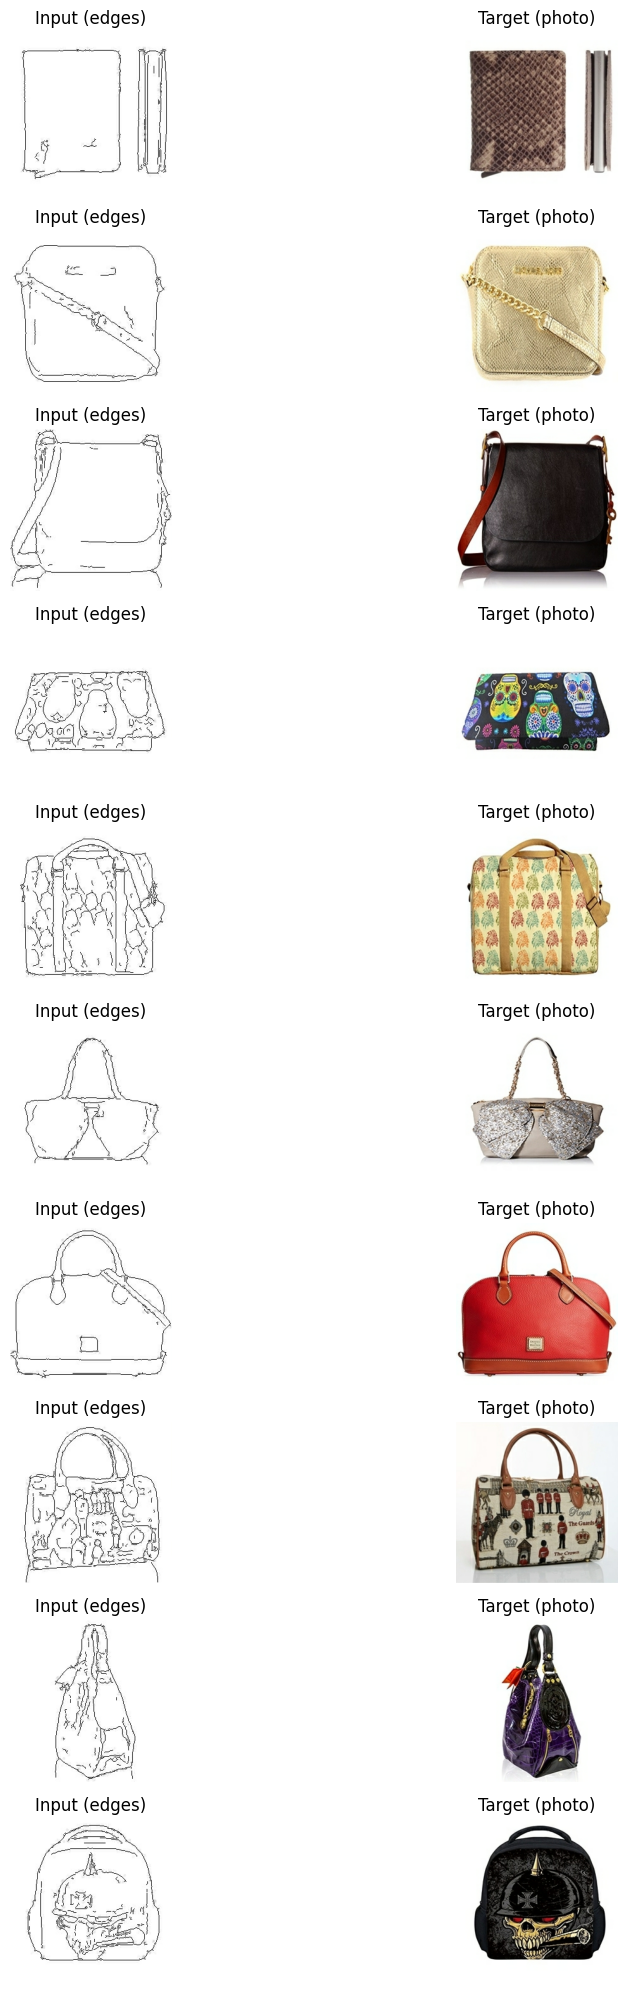

In [5]:
import tensorflow as tf
from matplotlib import pyplot as plt
import pathlib

# Chemin vers le dataset
PATH = pathlib.Path("/Data/roman.lendormy/.kaggle_cache/edges2handbags_extracted/edges2handbags")
train_path = PATH / "train"

# Récupérer les 10 premières images
image_files = sorted(list(train_path.iterdir()))[:10]

plt.figure(figsize=(12, 20))

for i, img_path in enumerate(image_files):
    # Lire l'image
    img = tf.io.read_file(str(img_path))
    img = tf.io.decode_jpeg(img)
    
    # Chaque image est 256x512 : split gauche/droite
    input_img = img[:, :256, :]   # edges
    target_img = img[:, 256:, :]  # photo
    
    # Affichage input
    plt.subplot(10, 2, 2*i + 1)
    plt.imshow(input_img)
    plt.title("Input (edges)")
    plt.axis("off")
    
    # Affichage target
    plt.subplot(10, 2, 2*i + 2)
    plt.imshow(target_img)
    plt.title("Target (photo)")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Pre-processing the data

In [ ]:
# """
# Prépare les images pour l'entraînement StyleGAN2
# - Redimensionne à 256x256
# - Centre et crop
# - Crée un dataset.zip
# """

# import os
# import zipfile
# from pathlib import Path
# from PIL import Image
# from tqdm import tqdm
# import argparse

# def prepare_images(input_dir, output_dir, resolution=256):
#     """
#     Prépare les images : resize, center crop, sauvegarde
#     """
#     input_path = Path(input_dir)
#     output_path = Path(output_dir)
#     output_path.mkdir(parents=True, exist_ok=True)
    
#     # Extensions supportées
#     extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    
#     # Lister toutes les images
#     image_files = [
#         f for f in input_path.rglob('*') 
#         if f.suffix.lower() in extensions
#     ]
    
#     print(f"📸 Trouvé {len(image_files)} images dans {input_dir}")
    
#     if len(image_files) < 1000:
#         print("⚠️  ATTENTION : Moins de 1000 images détectées.")
#         print("   Recommandé : 5000+ pour de bons résultats")
    
#     # Traiter chaque image
#     for idx, img_path in enumerate(tqdm(image_files, desc="Processing")):
#         try:
#             # Charger image
#             img = Image.open(img_path).convert('RGB')
            
#             # Center crop au ratio carré
#             width, height = img.size
#             min_side = min(width, height)
            
#             left = (width - min_side) // 2
#             top = (height - min_side) // 2
#             right = left + min_side
#             bottom = top + min_side
            
#             img_cropped = img.crop((left, top, right, bottom))
            
#             # Resize à la résolution cible
#             img_resized = img_cropped.resize(
#                 (resolution, resolution), 
#                 Image.LANCZOS
#             )
            
#             # Sauvegarder avec nouveau nom
#             output_filename = f"{idx:06d}.png"
#             img_resized.save(output_path / output_filename, quality=95)
            
#         except Exception as e:
#             print(f"❌ Erreur avec {img_path}: {e}")
#             continue
    
#     print(f"✅ {len(list(output_path.glob('*.png')))} images préparées")
#     return output_path



In [ ]:
# def create_zip_dataset(image_dir, output_zip):
#     """
#     Crée un fichier .zip du dataset (format requis par StyleGAN2)
#     """
#     image_path = Path(image_dir)
#     images = sorted(image_path.glob('*.png'))
    
#     print(f"📦 Création du .zip avec {len(images)} images...")
    
#     with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_STORED) as zipf:
#         for img in tqdm(images, desc="Zipping"):
#             # Ajouter au zip avec chemin relatif
#             zipf.write(img, arcname=img.name)
    
#     print(f"✅ Dataset créé : {output_zip}")
#     print(f"   Taille : {Path(output_zip).stat().st_size / 1e9:.2f} GB")

In [7]:
import os
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import zipfile
import shutil

def prepare_real_images_only(input_dir, output_dir, resolution=256):
    """
    Prépare uniquement la partie photo réelle des images 256x512.
    - Crop à la moitié droite
    - Center crop si nécessaire
    - Resize à resolution x resolution
    """
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    
    # Supprime l'ancien dossier si il existe
    if output_path.exists():
        shutil.rmtree(output_path)
    output_path.mkdir(parents=True, exist_ok=True)
    
    extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    image_files = [f for f in input_path.rglob('*') if f.suffix.lower() in extensions]
    print(f"📸 Trouvé {len(image_files)} images dans {input_dir}")
    
    for idx, img_path in enumerate(tqdm(image_files, desc="Processing")):
        try:
            img = Image.open(img_path).convert('RGB')
            w, h = img.size
            # Garder la moitié droite (photo réelle)
            img_real = img.crop((w//2, 0, w, h))
            
            # Center crop au cas où ce n'est pas carré
            width, height = img_real.size
            min_side = min(width, height)
            left = (width - min_side) // 2
            top = (height - min_side) // 2
            img_cropped = img_real.crop((left, top, left + min_side, top + min_side))
            
            # Resize
            img_resized = img_cropped.resize((resolution, resolution), Image.LANCZOS)
            
            # Sauvegarder
            output_filename = f"{idx:06d}.png"
            img_resized.save(output_path / output_filename, quality=95)
        except Exception as e:
            print(f"❌ Erreur avec {img_path}: {e}")
            continue
            
    print(f"✅ {len(list(output_path.glob('*.png')))} images préparées")
    return output_path

def create_zip_dataset(image_dir, output_zip):
    image_path = Path(image_dir)
    images = sorted(image_path.glob('*.png'))
    print(f"📦 Création du .zip avec {len(images)} images...")
    
    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_STORED) as zipf:
        for img in tqdm(images, desc="Zipping"):
            zipf.write(img, arcname=img.name)
    
    print(f"✅ Dataset créé : {output_zip}")
    print(f"Taille : {Path(output_zip).stat().st_size / 1e9:.2f} GB")
    return output_zip


In [12]:
input_dir = "/Data/roman.lendormy/.kaggle_cache/edges2handbags_extracted/edges2handbags/train"
temp_processed_dir = "/Data/roman.lendormy/s2p_dataset_processed"
output_zip = "/Data/roman.lendormy/s2p_dataset_processed/edges2handbags_256.zip"

# Étape 1 : Préparer les images
processed_dir = prepare_real_images_only(input_dir, temp_processed_dir, resolution=256)

# Étape 2 : Créer le zip
zip_path = create_zip_dataset(processed_dir, output_zip)


📸 Trouvé 138567 images dans /Data/roman.lendormy/.kaggle_cache/edges2handbags_extracted/edges2handbags/train


Processing:   1%|          | 1106/138567 [00:07<15:40, 146.15it/s]

Processing: 100%|██████████| 138567/138567 [16:06<00:00, 143.34it/s]


✅ 138567 images préparées
📦 Création du .zip avec 138567 images...


Zipping: 100%|██████████| 138567/138567 [00:10<00:00, 12875.59it/s]


✅ Dataset créé : /Data/roman.lendormy/s2p_dataset_processed/edges2handbags_256.zip
Taille : 8.95 GB


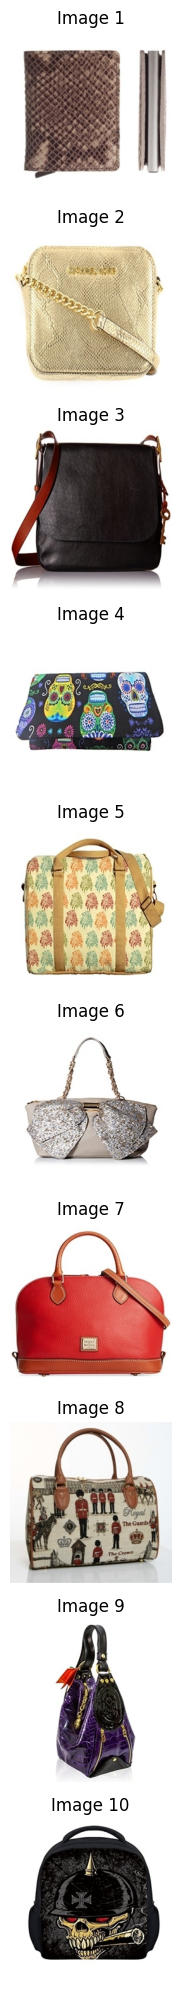

In [13]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Dossier contenant les images traitées
processed_dir = Path("/Data/roman.lendormy/s2p_dataset_processed")

# Récupérer les 10 premières images PNG
image_files = sorted(list(processed_dir.glob('*.png')))[:10]

plt.figure(figsize=(10, 20))

for i, img_path in enumerate(image_files):
    img = Image.open(img_path).convert('RGB')
    
    plt.subplot(10, 1, i + 1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()
